In [46]:
from datetime import datetime, timedelta
import pickle
import os
import os.path
from scipy.spatial import cKDTree
import grib2io
import sys

sys.path.append('../sdpm_py_util')
import grid_functions as grdfuns
import ocn_funs_forecast as ocnfuns
import init_funs as initfuns

import numpy as np
import xarray as xr
import netCDF4 as nc
from netCDF4 import Dataset

from scipy.interpolate import RegularGridInterpolator, LinearNDInterpolator
from scipy.interpolate import interp1d

#import seawater
import subprocess
from concurrent.futures import ThreadPoolExecutor, as_completed

#import util_functions as utlfuns 
from util_functions import s_coordinate_4
#from pydap.client import open_url
#import sys
import matplotlib.pyplot as plt


In [4]:
fn_atm = '/scratch/PHM_Simulations/riv_vpfm/LV4_Forecast/Forc/LV4_ATM_FORCING.nc'

ds = nc.Dataset(fn_atm)
swrad = ds.variables['swrad']
print(swrad)
print(swrad[:,0,0])


<class 'netCDF4.Variable'>
float64 swrad(srf_time, er, xr)
    _FillValue: nan
    long_name: net solar short wave radiation flux down
    units: W/m^2
    coordinates: lat,lon
    time: srf_time
    negative values: upward flux, cooling
    positive values: downward flux, warming
unlimited dimensions: 
current shape = (9, 1141, 486)
filling on
[386.62328549   0.           0.           0.           0.
 166.96036158 513.61379003 600.99677722 212.63372426]


Variable: DSWRF (Downward Short-Wave Radiation Flux)
packing type is: 30
Decimal Scale Factor: 1
Binary Scale Factor: 0
Reference Value: 0.0
1
['__annotations__', '__class__', '__dataclass_fields__', '__dataclass_params__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__match_args__', '__module__', '__ne__', '__new__', '__post_init__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setitem__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_attrs', '_auto_nans', '_coordlist', '_data', '_deflist', '_dxsign', '_dysign', '_earthparams', '_fixedsfc1info', '_fixedsfc2info', '_generate_signature', '_isAerosol', '_isNDFD', '_len', '_lldivisor', '_llscalefactor', '_msgnum', '_num', '_ondiskarray', '_orig_section5', '_packingScheme', '_sha1_section3', '_signature', '_varinfo', '_xydivisor', 'attrs_by_sect

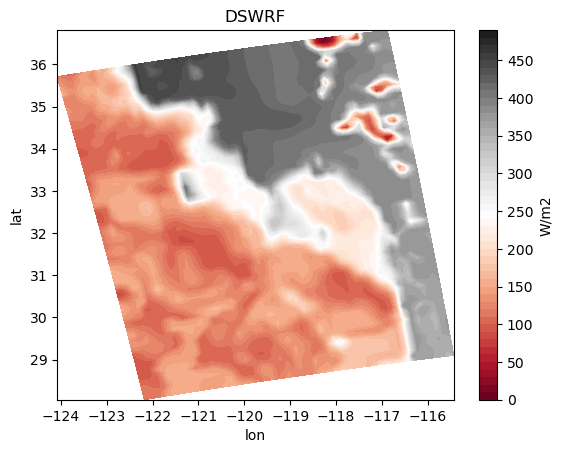

In [56]:
lt_mn = 118 # these are the indices of the nam 12 km simulation that get 
lt_mx = 191 # a box of nam data that LV1 grid is totall within
ln_mn = 129
ln_mx = 185

fn_grb = '/dataSIO/PHM_Simulations/raw_download/nam_grb2/nam_218_20250823_0000_000.grb2'

g = grib2io.open(fn_grb)
messages = g.select(shortName='DSWRF')

if not messages:
    print("Variable 'DSWRF' not found in file.")
else:
    # Use the first matching message
    msg = messages[0]

    # 3. Access Packing Information from Section 5 (Data Representation Section)
    # grib2io provides human-readable meanings for integer codes
    packing_type = msg.gdtn  # Grid Data Template Number
    
    print(f"Variable: {msg.shortName} ({msg.fullName})")
    print('packing type is:', packing_type)
    
    # 4. Inspect specific scaling and precision details
    # These are commonly stored as attributes on the message object
    print(f"Decimal Scale Factor: {msg.decScaleFactor}")
    D = msg.decScaleFactor
    print(f"Binary Scale Factor: {msg.binScaleFactor}")
    B = msg.binScaleFactor
    print(f"Reference Value: {msg.refValue}")



AA1 = g.select(shortName='DSWRF',level='surface')[0]
print(AA1.decScaleFactor)
print(dir(AA1))


lats, lons = AA1.grid()
#print(np.shape(lats))
#print(lats[:,0])
#print(lons[0,:])
lons2 = lons[lt_mn:lt_mx,ln_mn:ln_mx]
lats2 = lats[lt_mn:lt_mx,ln_mn:ln_mx]


AA2 = AA1.data
swd = AA2[lt_mn:lt_mx,ln_mn:ln_mx]
print('short wave down from .data:')
print(swd[0,0])
print('original number, swd * 10**D divided by 2**B:')
print(swd[0,0] * (10**D) / (2**B))

swd_0 = swd

fig, ax = plt.subplots()
lvs=np.arange(0,500,10)
cf = ax.contourf(lons2, lats2, swd, levels=lvs, cmap='RdGy') # 'levels' specifies number of contour intervals, 'cmap' sets the color scheme
# 3. Add a color bar to indicate the values represented by colors
fig.colorbar(cf, ax=ax, label='W/m2')
# 4. Add titles and labels
ax.set_title('DSWRF')
ax.set_xlabel('lon')
ax.set_ylabel('lat')



AA1 = g.select(shortName='USWRF',level='surface')[0]
AA2 = AA1.data
swu = AA2[lt_mn:lt_mx,ln_mn:ln_mx]

sw_net = swd - swu

print(np.mean(swd))
print(swd[:,0])
print(swu[:,0])

AA1 = g.select(shortName='TMP',level='surface')[0]
AA2 = AA1.data
tmp = AA2[lt_mn:lt_mx,ln_mn:ln_mx]
print(np.mean(tmp))
print(tmp[:,0])

AA1 = g.select(shortName='UGRD',level='10 m above ground')[0]
AA2 = AA1.data
AA3 = AA2[lt_mn:lt_mx,ln_mn:ln_mx]
print(np.mean(AA3))
print(AA3[:,0])   


Variable: DSWRF (Downward Short-Wave Radiation Flux)
packing type is: 30
Decimal Scale Factor: -1
Binary Scale Factor: 0
Reference Value: 0.0
Reference Value: 0.0
short wave down from .data:
140.0
original number, swd * 10**D divided by 2**B:
14.0
252.65656
[140. 140. 130. 130. 120. 110. 110. 110. 110. 110. 110. 120. 130. 120.
 130. 130. 110. 110. 120. 120. 130. 120. 100.  90. 100. 110. 120. 130.
 130. 130. 120. 120. 130. 130. 130. 120. 120. 120. 120. 120. 120. 120.
 110. 120. 130. 120. 100. 100. 100. 100. 110. 110. 110. 110. 110. 110.
 110. 110. 120. 110. 120. 120. 130. 140. 140. 150. 150. 140. 140. 140.
 140. 140. 130.]
[ 9.1        9.1        9.         8.7        7.9        7.4
  7.5        7.4        7.4        7.5        7.7000003  9.400001
 10.6       10.        11.5       10.8        9.1        8.8
 10.5       11.400001  11.900001  10.900001   8.1        6.4
  7.         9.5       11.8       11.8       11.8       11.5
 10.1        8.900001   9.400001   8.900001   8.5        8.8

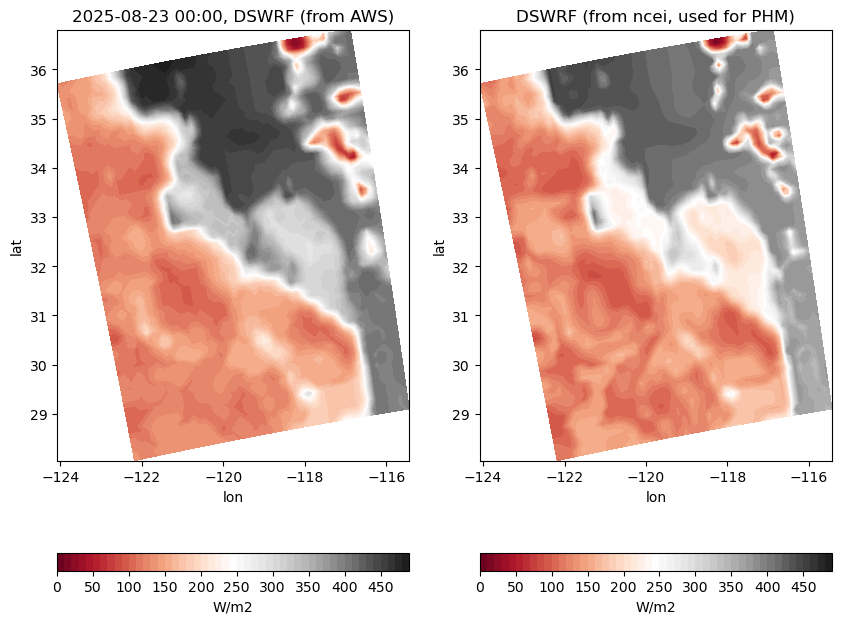

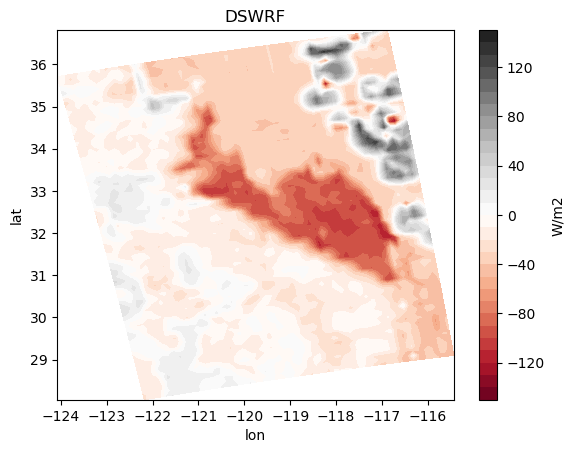

In [64]:
lt_mn = 118 # these are the indices of the nam 12 km simulation that get 
lt_mx = 191 # a box of nam data that LV1 grid is totall within
ln_mn = 129
ln_mx = 185


fn_grb = '/home/mspydell/dum_20250823_00_00.grb2'
g = grib2io.open(fn_grb)

messages = g.select(shortName='DSWRF')

if not messages:
    print("Variable 'DSWRF' not found in file.")
else:
    # Use the first matching message
    msg = messages[0]

    # 3. Access Packing Information from Section 5 (Data Representation Section)
    # grib2io provides human-readable meanings for integer codes
    packing_type = msg.gdtn  # Grid Data Template Number
    
    print(f"Variable: {msg.shortName} ({msg.fullName})")
    print('packing type is:', packing_type)
    
    # 4. Inspect specific scaling and precision details
    # These are commonly stored as attributes on the message object
    print(f"Decimal Scale Factor: {msg.decScaleFactor}")
    D = msg.decScaleFactor
    print(f"Binary Scale Factor: {msg.binScaleFactor}")
    B = msg.binScaleFactor
    print(f"Reference Value: {msg.refValue}")
    print(f"Reference Value: {msg.refValue}")


AA1 = g.select(shortName='DSWRF',level='surface')[0]

lats, lons = AA1.grid()
#print(np.shape(lats))
#print(lats[:,0])
#print(lons[0,:])
lons2 = lons[lt_mn:lt_mx,ln_mn:ln_mx]
lats2 = lats[lt_mn:lt_mx,ln_mn:ln_mx]


AA2 = AA1.data
swd = AA2[lt_mn:lt_mx,ln_mn:ln_mx]

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(10,8))
lvs=np.arange(0,500,10)
cf1 = ax1.contourf(lons2, lats2, swd, levels=lvs, cmap='RdGy') # 'levels' specifies number of contour intervals, 'cmap' sets the color scheme
# 3. Add a color bar to indicate the values represented by colors
# 4. Add titles and labels
ax1.set_title('2025-08-23 00:00, DSWRF (from AWS)')
ax1.set_xlabel('lon')
ax1.set_ylabel('lat')
fig.colorbar(cf1, ax=ax1, orientation='horizontal', label='W/m2')


cf2 = ax2.contourf(lons2, lats2, swd_0, levels=lvs, cmap='RdGy') # 'levels' specifies number of contour intervals, 'cmap' sets the color scheme
# 3. Add a color bar to indicate the values represented by colors
# 4. Add titles and labels
ax2.set_title('DSWRF (from ncei, used for PHM)')
ax2.set_xlabel('lon')
ax2.set_ylabel('lat')
fig.colorbar(cf2, ax=ax2, orientation='horizontal', label='W/m2')


fig, ax = plt.subplots()
lvs=np.arange(-150,160,10)
cf = ax.contourf(lons2, lats2, swd_0 - swd, levels=lvs, cmap='RdGy') # 'levels' specifies number of contour intervals, 'cmap' sets the color scheme
# 3. Add a color bar to indicate the values represented by colors
fig.colorbar(cf, ax=ax, label='W/m2')
# 4. Add titles and labels
ax.set_title('DSWRF')
ax.set_xlabel('lon')
ax.set_ylabel('lat')


print('short wave down from .data:')
print(swd[0,0])
print('original number, swd * 10**D divided by 2**B:')
print(swd[0,0] * (.1) / (2**B))

AA1 = g.select(shortName='USWRF',level='surface')[0]
AA2 = AA1.data
swu = AA2[lt_mn:lt_mx,ln_mn:ln_mx]

sw_net = swd - swu

print(np.mean(swd))
print(swd[:,0])
print(swu[:,0])

AA1 = g.select(shortName='TMP',level='surface')[0]
AA2 = AA1.data
tmp = AA2[lt_mn:lt_mx,ln_mn:ln_mx]
print(np.mean(tmp))
print(tmp[:,0])

AA1 = g.select(shortName='UGRD',level='10 m above ground')[0]
AA2 = AA1.data
AA3 = AA2[lt_mn:lt_mx,ln_mn:ln_mx]
print(np.mean(AA3))
print(AA3[:,0])   



In [18]:
fn_atm = '/scratch/PFM_Simulations/LV4_Forecast/Forc/LV4_ATM_FORCING.nc'

ds = nc.Dataset(fn_atm)
swrad = ds.variables['swrad']
print(swrad)
print(swrad[:,0,0])


<class 'netCDF4.Variable'>
float64 swrad(srf_time, er, xr)
    _FillValue: nan
    long_name: net solar short wave radiation flux down
    units: W/m^2
    coordinates: lat,lon
    time: srf_time
    negative values: upward flux, cooling
    positive values: downward flux, warming
unlimited dimensions: 
current shape = (102, 1141, 486)
filling on
[ 5.97744389e+01  5.97744389e+01  3.23004333e-03 -1.94578211e-02
  0.00000000e+00  5.43167967e-02  0.00000000e+00  1.73611111e-05
  1.73611111e-05  0.00000000e+00  1.73611111e-05  1.73611111e-05
 -3.45115444e-03  3.46851556e-03  1.73611111e-05  2.41215539e-01
  6.87359927e+01  2.29743465e+02  3.87624423e+02  5.05464721e+02
  5.67187469e+02  5.65151629e+02  4.99799288e+02  3.78442392e+02
  2.17956010e+02  5.95468636e+01  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  2.77813476e-01
 